## Thiết lập môi trường và chia dữ liệu

In [1]:
import os
import time
import copy
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

In [2]:

# 1. Đường dẫn dữ liệu trên Kaggle
BASE_PATH = '/kaggle/input/competitions/state-farm-distracted-driver-detection'
df = pd.read_csv(os.path.join(BASE_PATH, 'driver_imgs_list.csv'))

# 2. Chia theo Subject ID (Tài xế) để tránh Overfitting
drivers = df['subject'].unique()
train_drivers, val_drivers = train_test_split(drivers, test_size=0.2, random_state=42)

# 3. Tạo danh sách file cho tập Train và Val
train_df = df[df['subject'].isin(train_drivers)].reset_index(drop=True)
val_df = df[df['subject'].isin(val_drivers)].reset_index(drop=True)

# 4. Xuất ra file CSV dùng chung
train_df.to_csv('train_list.csv', index=False)
val_df.to_csv('val_list.csv', index=False)

print(f" Train: {len(train_df)} ảnh, Val: {len(val_df)} ảnh.")

 Train: 17446 ảnh, Val: 4978 ảnh.


In [ ]:
!pip install ultralytics -q
from ultralytics import YOLO
import cv2
import os
from tqdm import tqdm

BASE_PATH = '/kaggle/input/competitions/state-farm-distracted-driver-detection'
TRAIN_DIR = os.path.join(BASE_PATH, 'imgs', 'train')
# 1. Khởi tạo mô hình YOLOv8 nano (rất nhanh)
yolo_detector = YOLO('yolov8n.pt')

# 2. Tạo thư mục chứa ảnh đã cắt
CROP_DIR = '/kaggle/working/cropped_images'
os.makedirs(CROP_DIR, exist_ok=True)
for i in range(10):
    os.makedirs(os.path.join(CROP_DIR, f'c{i}'), exist_ok=True)

def preprocess_dataset(dataframe, source_dir, target_dir):
    print("🚀 Đang tiến hành cắt ảnh bằng YOLOv8...")
    for idx, row in tqdm(dataframe.iterrows(), total=len(dataframe)):
        img_path = os.path.join(source_dir, row['classname'], row['img'])
        save_path = os.path.join(target_dir, row['classname'], row['img'])
        
        # Chạy YOLO phát hiện người (class 0)
        results = yolo_detector(img_path, verbose=False)
        img = cv2.imread(img_path)
        
        found = False
        for r in results:
            for box in r.boxes:
                if int(box.cls) == 0: # Nếu là người
                    x1, y1, x2, y2 = map(int, box.xyxy[0])
                    # Cắt và lưu
                    crop_img = img[y1:y2, x1:x2]
                    if crop_img.size > 0:
                        cv2.imwrite(save_path, crop_img)
                        found = True
                    break
            if found: break
            
        # Nếu không tìm thấy người, copy ảnh gốc sang để không mất dữ liệu
        if not found:
            cv2.imwrite(save_path, img)

# Chạy tiền xử lý cho toàn bộ ảnh 
# Lưu ý: Chỉ cần chạy 1 lần. 
# Nếu muốn nhanh hơn để test, bạn có thể chỉ chạy trên val_df trước.
preprocess_dataset(df, TRAIN_DIR, CROP_DIR)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 21.2 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
🚀 Đang tiến hành cắt ảnh bằng YOLOv8...


100%|██████████| 22424/22424 [09:27<00:00, 39.49it/s]


## Xây dựng bộ nạp dữ liệu

In [4]:
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from PIL import Image
import os

train_transforms = transforms.Compose([
    # Quan trọng: Cắt ngẫu nhiên giúp mô hình không học thuộc vị trí
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)), 
    transforms.RandomHorizontalFlip(p=0.5), 
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# 2. Custom Dataset (Đảm bảo đọc đúng từ CROP_DIR của YOLO)
class CroppedDriverDataset(Dataset):
    def __init__(self, dataframe, root_dir, transform=None):
        self.dataframe = dataframe
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        img_path = os.path.join(self.root_dir, row['classname'], row['img'])
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        
        # Chuyển classname (c0, c1...) thành số (0, 1...)
        label = int(row['classname'][1:])
        return image, label

# 3. Khởi tạo Dataset & DataLoader
# LƯU Ý: Đặt num_workers=0 để dứt điểm lỗi AssertionError
train_dataset = CroppedDriverDataset(train_df, CROP_DIR, transform=train_transforms)
val_dataset = CroppedDriverDataset(val_df, CROP_DIR, transform=val_transforms)

train_loader = DataLoader(
    train_dataset, 
    batch_size=32, 
    shuffle=True, 
    num_workers=0,  # Sửa lỗi: Không dùng đa luồng để tránh xung đột
    pin_memory=False
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=32, 
    shuffle=False, 
    num_workers=0, 
    pin_memory=False
)

print(f"✅ Đã tải {len(train_dataset)} ảnh train và {len(val_dataset)} ảnh val.")
print("🚀 Lỗi Multiprocessing đã được khắc phục bằng cách đặt num_workers=0.")

✅ Đã tải 17446 ảnh train và 4978 ảnh val.
🚀 Lỗi Multiprocessing đã được khắc phục bằng cách đặt num_workers=0.


## MobileNetV3

In [ ]:

import torch
import torch.nn as nn
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.mobilenet_v3_large(weights='IMAGENET1K_V1')

# Lấy số feature đầu vào của classifier
num_ftrs = model.classifier[0].in_features 

# Thay thế toàn bộ classifier để có sức mạnh tính toán tốt hơn
model.classifier = nn.Sequential(
    nn.Linear(num_ftrs, 1024),
    nn.Hardswish(),
    nn.Dropout(p=0.6), # Tăng cường độ Dropout
    nn.Linear(1024, 10)
)
model = model.to(device)
print("✅ Đã nâng cấp Classifier với 1024 neurons!")

Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-8738ca79.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-8738ca79.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 134MB/s] 


✅ Đã nâng cấp Classifier với 1024 neurons!


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

# 1. Thiết lập trọng số lớp (Tăng ưu tiên cho c0 và c9)
# c9 được nhân 4 lần để bù đắp việc khó nhận diện
weights = torch.tensor([2.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 4.0]).to(device)

# 2. Loss Function với Label Smoothing để chống Overfitting
criterion = nn.CrossEntropyLoss(weight=weights, label_smoothing=0.1)

# 3. Optimizer AdamW
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.05)

# 4. OneCycleLR Scheduler (Đã sửa lỗi khởi tạo LR)
num_epochs = 15
steps_per_epoch = len(train_loader)

scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer, 
    max_lr=1e-4, 
    epochs=num_epochs,
    steps_per_epoch=steps_per_epoch,
    pct_start=0.3,       # 30% thời gian đầu tăng LR lên max
    div_factor=10,       # LR khởi đầu = max_lr / 10
    final_div_factor=100, # LR kết thúc = max_lr / 100
    anneal_strategy='cos'
)

print(f"✅  Đã sẵn sàng 15 Epochs với {steps_per_epoch} steps mỗi Epoch.")

✅ Cell 5 hoàn tất: Đã sẵn sàng 15 Epochs với 546 steps mỗi Epoch.


In [7]:
import numpy as np
import torch

# --- Hàm hỗ trợ Mixup ---
def mixup_data(x, y, alpha=0.2):
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1
    batch_size = x.size(0)
    index = torch.randperm(batch_size).to(device)
    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

# --- Bắt đầu Training ---
best_val_acc = 0.0
total_steps = num_epochs * steps_per_epoch

print(f"🚀 Bắt đầu huấn luyện: Mixup + OneCycleLR")

for epoch in range(num_epochs):
    model.train()
    running_loss, correct_train, total_train = 0.0, 0, 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        
        # Áp dụng Mixup ngẫu nhiên 50% số batch
        if np.random.random() > 0.5:
            mixed_images, labels_a, labels_b, lam = mixup_data(images, labels, alpha=0.2)
            outputs = model(mixed_images)
            loss = mixup_criterion(criterion, outputs, labels_a, labels_b, lam)
        else:
            outputs = model(images)
            loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        # CẬP NHẬT LR THEO TỪNG BATCH (Quan trọng)
        scheduler.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    # --- Validation ---
    model.eval()
    correct_val, total_val = 0, 0
    val_loss = 0.0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()
    
    # Chỉ số cuối mỗi Epoch
    train_acc = 100 * correct_train / total_train
    val_acc = 100 * correct_val / total_val
    # Lấy LR hiện tại chính xác từ optimizer
    current_lr = optimizer.param_groups[0]['lr']
    
    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"  > Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")
    print(f"  > LR: {current_lr:.8f} | Loss: {running_loss/steps_per_epoch:.4f}")
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_driver_model_final.pth')
        print(f"  🌟 Đã lưu mô hình mới: {best_val_acc:.2f}%")
    print("-" * 30)

print(f"✅ HOÀN TẤT! Độ chính xác cao nhất: {best_val_acc:.2f}%")

🚀 Bắt đầu huấn luyện: Mixup + OneCycleLR
Epoch [1/15]
  > Train Acc: 13.85% | Val Acc: 28.73%
  > LR: 0.00002054 | Loss: 1.9568
  🌟 Đã lưu mô hình mới: 28.73%
------------------------------
Epoch [2/15]
  > Train Acc: 57.25% | Val Acc: 79.41%
  > LR: 0.00004721 | Loss: 1.2057
  🌟 Đã lưu mô hình mới: 79.41%
------------------------------
Epoch [3/15]
  > Train Acc: 72.41% | Val Acc: 85.05%
  > LR: 0.00007753 | Loss: 0.7523
  🌟 Đã lưu mô hình mới: 85.05%
------------------------------
Epoch [4/15]
  > Train Acc: 76.14% | Val Acc: 83.31%
  > LR: 0.00009730 | Loss: 0.7109
------------------------------
Epoch [5/15]
  > Train Acc: 77.65% | Val Acc: 85.03%
  > LR: 0.00009944 | Loss: 0.6759
------------------------------
Epoch [6/15]
  > Train Acc: 74.58% | Val Acc: 87.69%
  > LR: 0.00009504 | Loss: 0.6799
  🌟 Đã lưu mô hình mới: 87.69%
------------------------------
Epoch [7/15]
  > Train Acc: 76.89% | Val Acc: 87.00%
  > LR: 0.00008665 | Loss: 0.6650
------------------------------
Epoch [8/


📊 BÁO CÁO CHI TIẾT HIỆU SUẤT MÔ HÌNH:
              precision    recall  f1-score   support

          c0       0.67      0.90      0.77       564
          c1       1.00      0.90      0.94       474
          c2       0.97      0.99      0.98       501
          c3       0.96      0.98      0.97       536
          c4       0.98      0.90      0.94       531
          c5       0.83      0.98      0.90       526
          c6       0.99      0.93      0.96       530
          c7       0.98      0.94      0.96       480
          c8       0.78      0.84      0.81       400
          c9       0.91      0.48      0.63       436

    accuracy                           0.89      4978
   macro avg       0.91      0.88      0.89      4978
weighted avg       0.91      0.89      0.89      4978



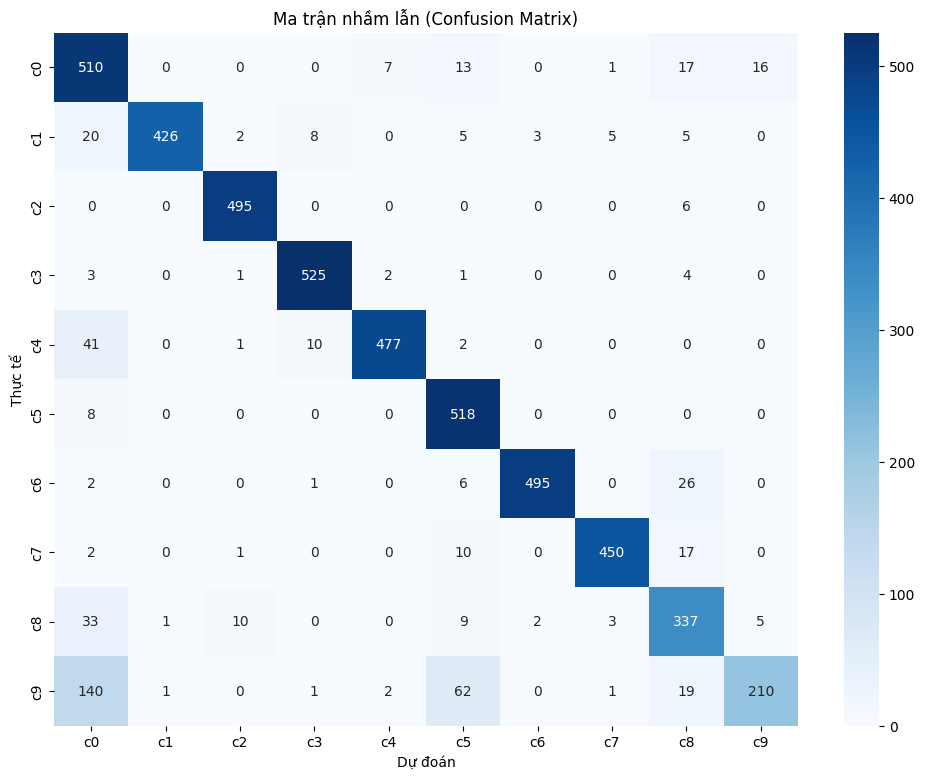

In [8]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
# Tải lại trọng số tốt nhất trước khi đánh giá
model.load_state_dict(torch.load('best_driver_model_final.pth'))
model.eval()

y_true, y_pred = [], []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        y_true.extend(labels.numpy())
        y_pred.extend(predicted.cpu().numpy())

# 1. Xuất báo cáo chi tiết
# class_names đã được định nghĩa ở Cell 1
print("\n📊 BÁO CÁO CHI TIẾT HIỆU SUẤT MÔ HÌNH:")
print(classification_report(y_true, y_pred, target_names=[f"c{i}" for i in range(10)]))

# 2. Vẽ Ma trận nhầm lẫn (Confusion Matrix) bằng Seaborn cho chuyên nghiệp
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 9))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=[f"c{i}" for i in range(10)], 
            yticklabels=[f"c{i}" for i in range(10)])
plt.title('Ma trận nhầm lẫn (Confusion Matrix)')
plt.xlabel('Dự đoán')
plt.ylabel('Thực tế')
plt.show()